## **Presentación del proyecto**

### **Descripción del problema de negocio**

La empresa *Opinia*, dedicada al comercio electrónico y la oferta de servicios digitales, recibe miles de reseñas de usuarios cada mes.
Estas opiniones reflejan la experiencia de los clientes con los productos, los tiempos de entrega, la atención postventa y la calidad del servicio.

Hasta el momento, el análisis de estas reseñas se realizaba de forma manual o con métricas básicas (como el promedio de estrellas), lo cual resulta insuficiente para comprender el sentimiento real detrás de los comentarios.
La falta de un sistema inteligente limita la capacidad de la empresa para identificar áreas de mejora, anticipar insatisfacciones y evaluar de forma precisa la satisfacción del cliente.

Por ello, *Opinia* enfrenta el desafío de transformar texto no estructurado en conocimiento accionable, aplicando técnicas de **Procesamiento del Lenguaje Natural (NLP)** combinadas con modelos de **Machine Learning y Deep Learning**.
El objetivo es crear una solución automatizada capaz de interpretar el tono emocional de las reseñas y ofrecer información valiosa para la toma de decisiones estratégicas.

### **Objetivo general**

El objetivo principal de este proyecto es desarrollar un sistema integral de **análisis de sentimientos** que clasifique las reseñas de los clientes según su valoración y contenido textual, utilizando modelos de **aprendizaje automático y redes neuronales**.

Para lograrlo, se implementa un pipeline completo de **Procesamiento del Lenguaje Natural (NLP)** que incluye limpieza de texto, tokenización, eliminación de stopwords, lematización, vectorización mediante TF-IDF y el entrenamiento de modelos predictivos.

En particular, se emplean dos enfoques complementarios:
* **Regresión Logística (Machine Learning)** con representaciones TF-IDF.
* **Red Neuronal MLP (Deep Learning)** utilizando secuencias de texto procesadas.

El sistema permitirá a *Opinia*:
* Analizar automáticamente el sentimiento y la satisfacción de los clientes.
* Detectar patrones lingüísticos asociados a opiniones positivas o negativas.
* Obtener métricas cuantitativas para monitorear la calidad del servicio.
* Mejorar la toma de decisiones basada en datos y retroalimentación real de usuarios.


### **Origen de los datos**

El conjunto de datos se obtuvo de la plataforma **Kaggle** y está compuesto por dos variables principales:

* **Text:** contiene las opiniones de los clientes.

* **Rating:** representa la puntuación que los usuarios otorgaron a *Opinia*, en una escala del 1 al 5.

En total, el dataset cuenta con 2.350 registros, una cantidad adecuada para desarrollar este proyecto de Data Science.

## **Importación de librerías**

Antes de comenzar con el análisis, es fundamental importar las librerías necesarias. Estas librerías contienen funciones y herramientas especializadas que nos permitirán manipular datos, crear visualizaciones, procesar lenguaje natural (NLP), así como entrenar y evaluar modelos de Machine Learning y Deep Learning de manera eficiente.

In [ ]:
# Instalación de spaCy y el modelo en español
!pip install -q spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 70.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Instalación de TensorFlow
!pip install tensorflow

In [ ]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Limpieza de texto
import re
import unicodedata

# spaCy para procesamiento de texto
import spacy
nlp = spacy.load('es_core_news_sm')
from spacy.lang.es.stop_words import STOP_WORDS

# NLTK para procesamiento de texto
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

# Transformers para modelos de lenguaje
from transformers import pipeline

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
# Configuración de recursos de NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Para que Python no muestre errores
import warnings
warnings.filterwarnings('ignore')

## **Lectura de datos**

In [ ]:
# Carga y lectura del conjunto de datos

# El link original: https://drive.google.com/file/d/1lt1kU4VtEAb76uzMfr4PW8m6S4q4S3pK/view

# Extraer el ID del archivo (la parte entre /d/ y /view)
file_id = '1lt1kU4VtEAb76uzMfr4PW8m6S4q4S3pK'

# Crear el link de descarga directa
download_url = f'https://drive.google.com/uc?id={file_id}&export=download'

# Leer el CSV directamente
df = pd.read_csv(download_url)

In [ ]:
# Muestra de los primeros 5 registros
df.head()

,text,rating
0,"Nada especial, aunque el precio fue justo.",3.0
1,Superó mis expectativas totalmente.,5.0
2,Buen producto y excelente presentación. buen,4.0
3,Producto aceptable pero esperaba más.,2.0
4,Buen producto y excelente presentación.,4.0


In [ ]:
# Verificación los tipos de datos
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2350 entries, 0 to 2349
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    2340 non-null   object 
 1   rating  2345 non-null   float64
dtypes: float64(1), object(1)
memory usage: 36.8+ KB


In [ ]:
# Verificación si existen valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
text      10
rating     5
dtype: int64


In [ ]:
# Eliminación las filas con valores nulos
df = df.dropna(subset=['text', 'rating'])

In [ ]:
# Verificación que no queden valores nulos
print("\n Valores nulos después de la eliminación:")
print(df.isnull().sum())


 Valores nulos después de la eliminación:
text      0
rating    0
dtype: int64


## **EDA - Análisis exploratorio de datos**

In [ ]:
# Distribución de rating (para revisar balance)
print("Distribución de rating:")
print(df['rating'].value_counts().sort_index())

Distribución de rating:
rating
1.0    232
2.0    354
3.0    467
4.0    609
5.0    673
Name: count, dtype: int64


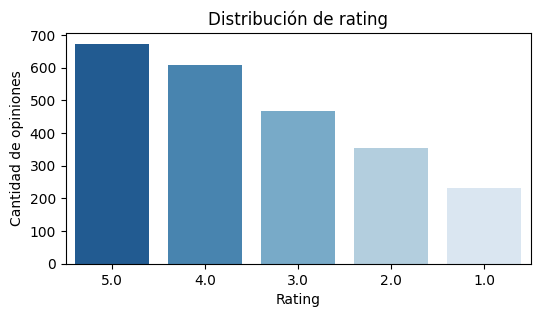

In [ ]:
# Muestra con gráfico de barras la distribución de rating
rating_counts = df['rating'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(6,3))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Blues')
plt.gca().invert_xaxis()
plt.xlabel('Rating')
plt.ylabel('Cantidad de opiniones')
plt.title('Distribución de rating')
plt.show()

El gráfico permite visualizar la frecuencia de cada nivel de calificación. La mayoría de las reseñas se concentran en valores altos del rating, indicando una tendencia hacia opiniones positivas.

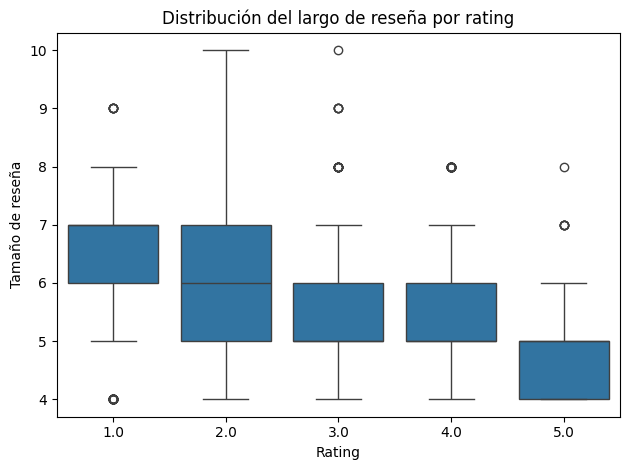

In [ ]:
# Distribución del largo de reseña por rating
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
sns.boxplot(x='rating', y='text_length', data=df)
plt.title("Distribución del largo de reseña por rating")
plt.ylabel("Tamaño de reseña")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

El gráfico permite observar la relación entre el rating y la longitud de las reseñas. Se comprobó que, a medida que aumenta la calificación, las reseñas tienden a ser más breves; en cambio, cuando la puntuación es baja, los comentarios suelen ser más extensos y detallados.

## **Limpieza de texto**

En esta etapa se va eliminar elementos que pueden dificultar el análisis, como mayúsculas, tildes, números, signos de puntuación y espacios extras. El objetivo es dejar únicamente las letras en un formato uniforme que los algoritmos puedan procesar de manera más eficiente.

In [ ]:
# Función de limpieza
def limpiar_texto(texto):
    # Se convierte todo a minúsculas
    texto = texto.lower()

    # Eliminación de tildes y normalización de caracteres especiales
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8', 'ignore')

    # Eliminación de números, signos y símbolos; deja solo letras y espacios
    texto = re.sub(r'[^a-zñ\s]', '', texto)

    # Eliminación de espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [ ]:
# Se Aplica la limpieza
df['clean_text_limpio'] = df['text'].apply(limpiar_texto)

In [ ]:
# Muestra de ejemplo
print("Ejemplo antes y después:")
display(df[['text', 'clean_text_limpio']].head())

Ejemplo antes y después:


,text,clean_text_limpio
0,"Nada especial, aunque el precio fue justo.",nada especial aunque el precio fue justo
1,Superó mis expectativas totalmente.,supero mis expectativas totalmente
2,Buen producto y excelente presentación. buen,buen producto y excelente presentacion buen
3,Producto aceptable pero esperaba más.,producto aceptable pero esperaba mas
4,Buen producto y excelente presentación.,buen producto y excelente presentacion


## **Tokenización**

### **¿Qué es?**

La **tokenización** es el proceso de dividir un texto en unidades más pequeñas llamadas "tokens" (generalmente palabras o subpalabras).

### **Ejemplo:**

*   Texto: "El lenguaje natural es fascinante"
*   Tokens: ["El", "lenguaje", "natural", "es", "fascinante"]

### **¿Para qué sirve?**

Es un paso fundamental en NLP porque:

*   **Los modelos no entienden texto crudo:** Necesitan convertir las palabras en números, y la tokenización es el primer paso.
*   **Define las unidades básicas de análisis:** Establece qué constituye una "palabra" o unidad de significado en el texto.
*   **Facilita el procesamiento:** Permite aplicar técnicas como embeddings, eliminación de palabras irrelevantes y análisis sintáctico.

En resumen, la tokenización traduce el texto humano a un formato que las máquinas pueden procesar y analizar.








In [ ]:
# Ejemplo básico con una reseña
texto_ejemplo = df['text'].iloc[0]
doc = nlp(texto_ejemplo)

print("Texto original:")
print(texto_ejemplo)
print("\n Tokens detectados:")
print([token.text for token in doc])

Texto original:
Nada especial, aunque el precio fue justo.

 Tokens detectados:
['Nada', 'especial', ',', 'aunque', 'el', 'precio', 'fue', 'justo', '.']


In [ ]:
# Tokenización sobre todo el dataset
df['clean_text_limpio'] = df['text'].apply(lambda x: [token.text for token in nlp(x)])

In [ ]:
# Muestra de algunas filas para revisar
print("Ejemplo antes y después de tokenización:")
df[['text', 'clean_text_limpio']].head()

Ejemplo antes y después de tokenización:


,text,clean_text_limpio
0,"Nada especial, aunque el precio fue justo.","[Nada, especial, ,, aunque, el, precio, fue, j..."
1,Superó mis expectativas totalmente.,"[Superó, mis, expectativas, totalmente, .]"
2,Buen producto y excelente presentación. buen,"[Buen, producto, y, excelente, presentación, ...."
3,Producto aceptable pero esperaba más.,"[Producto, aceptable, pero, esperaba, más, .]"
4,Buen producto y excelente presentación.,"[Buen, producto, y, excelente, presentación, .]"


## **Remover Stopwords**

### **¿Qué es?**

**Stopwords** son palabras muy comunes que aportan poco significado al análisis de texto, como artículos, preposiciones y conjunciones. Removerlas significa eliminarlas del texto antes de procesarlo.

### **Ejemplo:**

*   Texto original: "El gato está en la casa"
*   Sin stopwords: ["gato", "casa"]
*   Stopwords removidas: "El", "está", "en", "la"

### **¿Para qué sirve?**

Remover stopwords puede ser útil porque:

*   **Reduce el ruido:** Elimina palabras que no contribuyen al significado principal del texto.
*   **Disminuye la dimensionalidad:** Reduce el tamaño del vocabulario, haciendo el procesamiento más eficiente.
*   **Optimiza recursos:** Menos palabras significa menor tiempo de procesamiento y uso de memoria.

In [ ]:
# Función para eliminar stopwords
def eliminar_stopwords(texto):
    # Se convierte a string por si hay valores nulos o listas
    texto = str(texto)
    # Separación en palabras
    palabras = texto.split()
    # Se quitan los stopwords
    palabras_filtradas = [p for p in palabras if p.lower() not in stop_words]
    return ' '.join(palabras_filtradas)

In [ ]:
# Verificación de usar una columna que exista
print("Columnas actuales en el DataFrame:")
print(df.columns)

Columnas actuales en el DataFrame:
Index(['text', 'rating', 'text_length', 'clean_text_limpio', 'tokens'], dtype='object')


In [ ]:
# Como no existe 'clean_text', se usa directamente 'text'
columna_base = 'clean_text' if 'clean_text' in df.columns else 'text'

In [ ]:
# Se aplica la función sobre la columna base
df['clean_text_limpio'] = df[columna_base].apply(eliminar_stopwords)

In [ ]:
# Muestra de un ejemplo para verificar
print("Ejemplo antes y después de remover stopwords:")
display(df[[columna_base, 'clean_text_limpio']].head())

Ejemplo antes y después de remover stopwords:


,text,clean_text_limpio
0,"Nada especial, aunque el precio fue justo.","especial, aunque precio justo."
1,Superó mis expectativas totalmente.,Superó expectativas totalmente.
2,Buen producto y excelente presentación. buen,Buen producto excelente presentación. buen
3,Producto aceptable pero esperaba más.,Producto aceptable esperaba más.
4,Buen producto y excelente presentación.,Buen producto excelente presentación.


## **Lematización**

### **¿Qué es?**

La **lematización** es el proceso de reducir las palabras a su forma base o raíz llamada "lema" (la forma que aparecería en un diccionario).

### **Ejemplo:**

*   "corriendo", "corrió", "correr" → **"correr"**
*   "mejor", "bueno", "buenos" → **"bueno"**
*   "soy", "eres", "fue" → **"ser"**

### **¿Para qué sirve?**

La lematización es útil porque:

*   **Normaliza variaciones:** agrupa distintas formas de una palabra bajo un mismo concepto.
*   **Simplifica el vocabulario:** reduce palabras únicas sin perder significado.
*   **Mejora el análisis:** reconoce “amar”, “ama” y “amaba” como la misma idea.

En resumen, la lematización unifica las distintas formas gramaticales de una palabra en su versión básica, facilitando el análisis y reduciendo la complejidad del vocabulario.

In [ ]:
# Función para lematizar
def lematizar_texto(texto):
    doc = nlp(texto)
    lemas = [t.lemma_ for t in doc if t.is_alpha and t.lemma_ not in STOP_WORDS]
    return " ".join(lemas)

In [ ]:
# Se aplica la función
df['clean_text_limpio'] = df['text'].apply(lematizar_texto)

In [ ]:
# Muestra de un ejemplo del antes y después de lematización
print("Ejemplo antes y después de la lematización:")
display(df[['text', 'clean_text_limpio']].head())

Ejemplo antes y después de la lematización:


,text,clean_text_limpio
0,"Nada especial, aunque el precio fue justo.",especial precio justo
1,Superó mis expectativas totalmente.,superar expectativa totalmente
2,Buen producto y excelente presentación. buen,producto excelente presentación
3,Producto aceptable pero esperaba más.,Producto aceptable esperar
4,Buen producto y excelente presentación.,producto excelente presentación


## **Palabras más frecuentes**

In [ ]:
# Se unen todos los textos lematizados en una sola lista de palabras
all_words = " ".join(df['clean_text_limpio']).split()

# Se cuenta la frecuencia de cada palabra
word_counts = Counter(all_words)

# Obtención de las 15 palabras más comunes
top15 = word_counts.most_common(15)

# Muestra
print("15 palabras más frecuentes en 'lemmatization':")
for word, freq in top15:
    print(f"{word}: {freq}")


15 palabras más frecuentes en 'lemmatization':
atención: 308
calidad: 287
comprar: 275
rápido: 255
expectativa: 249
excelente: 247
cumplir: 209
llegar: 199
volver: 184
mejorar: 174
experiencia: 165
recomeir: 157
superar: 154
Producto: 153
increíble: 153


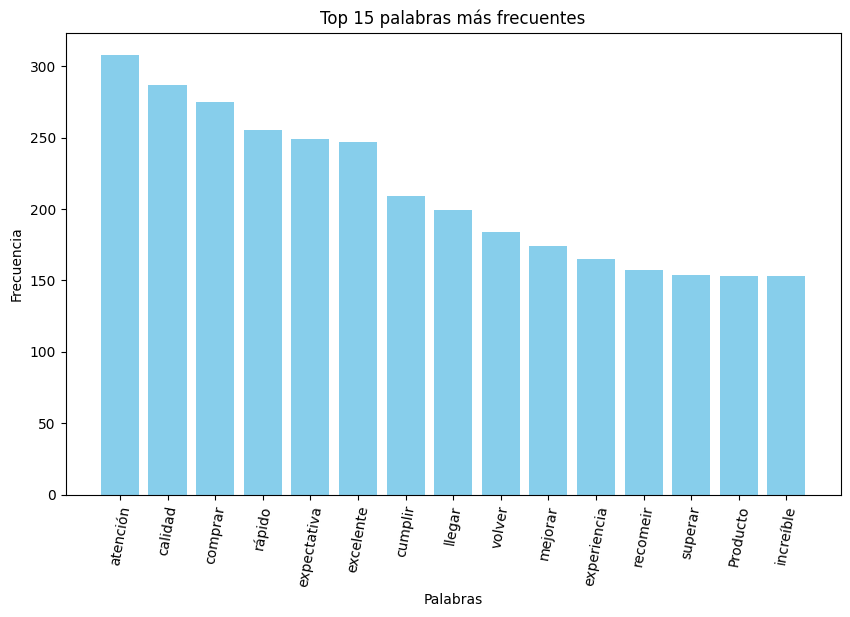

In [ ]:
# Separación de palabras y frecuencias
words, counts = zip(*top15)

# Creación de un gráfico
plt.figure(figsize=(10,6))
plt.bar(words, counts, color='skyblue')
plt.title("Top 15 palabras más frecuentes")
plt.xticks(rotation=80)
plt.ylabel("Frecuencia")
plt.xlabel("Palabras")
plt.show()

Después de la limpieza se observa las palabras más importantes del conjunto de datos.

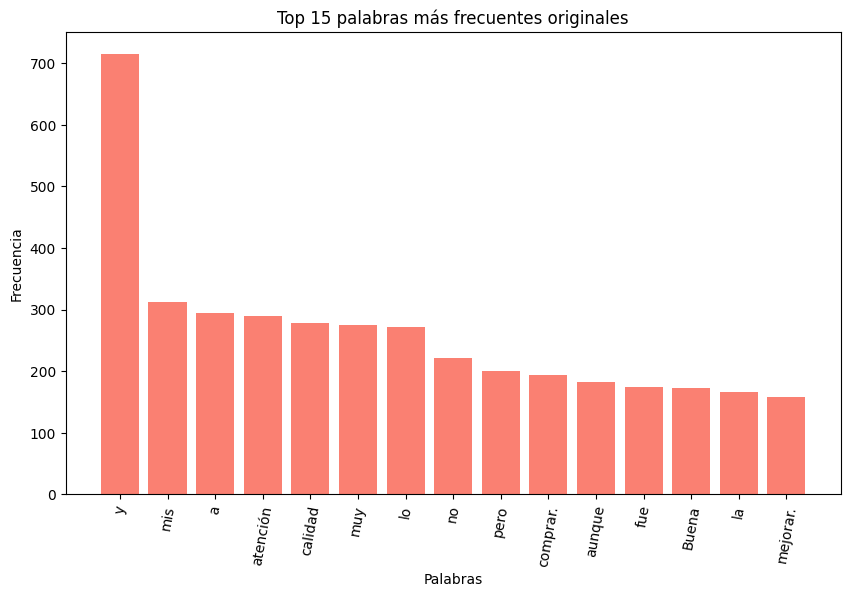

In [ ]:
# Se unen todos los textos originales
all_words_clean = " ".join(df['text']).split()

# Se cuenta
word_counts_clean = Counter(all_words_clean)
top20_clean = word_counts_clean.most_common(15)

# Se separan palabras y frecuencias
words_clean, counts_clean = zip(*top20_clean)

# Gráfico
plt.figure(figsize=(10,6))
plt.bar(words_clean, counts_clean, color='salmon')
plt.title("Top 15 palabras más frecuentes originales")
plt.xticks(rotation=80)
plt.ylabel("Frecuencia")
plt.xlabel("Palabras")
plt.show()

Si no se hubiese aplicado todas las limpiezas aparecerían otras palabras menos importantes.

##**Nubes de palabras**

En esta sección crearemos nubes de palabras para identificar visualmente los términos más utilizados en las reseñas. Además, generaremos nubes separadas para comentarios positivos y negativos, lo que nos permitirá comparar el vocabulario característico de cada tipo de opinión.

### **Nubes de palabras general**

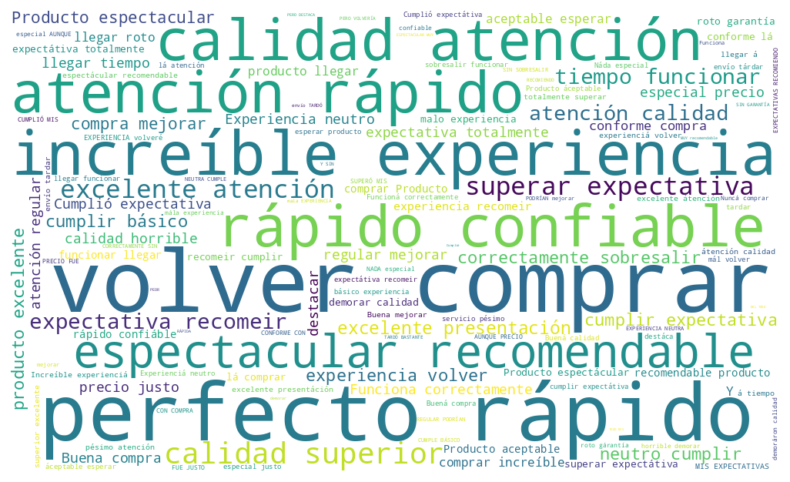

In [ ]:
# Se unen todos los textos limpios
texto_general = ' '.join(df['clean_text_limpio'])

# Se genera la nube
wordcloud_general = WordCloud(width=1000, height=600, background_color='white', colormap='viridis').generate(texto_general)

# Muestra
plt.figure(figsize=(10,6))
plt.imshow(wordcloud_general, interpolation='bilinear')
plt.axis('off')
plt.show()

### **Nubes de palabras positivas**

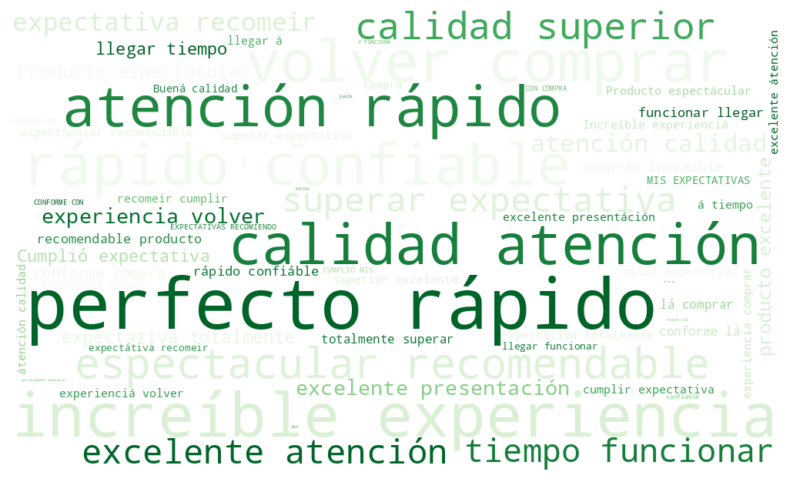

In [ ]:
# Se filtra reseñas positivas (con rating 4 y 5)
texto_positivo = ' '.join(df[df['rating'] >= 4]['clean_text_limpio'])

wordcloud_pos = WordCloud(width=1000, height=600, background_color='white', colormap='Greens').generate(texto_positivo)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.show()

### **Nubes de palabras negativas**

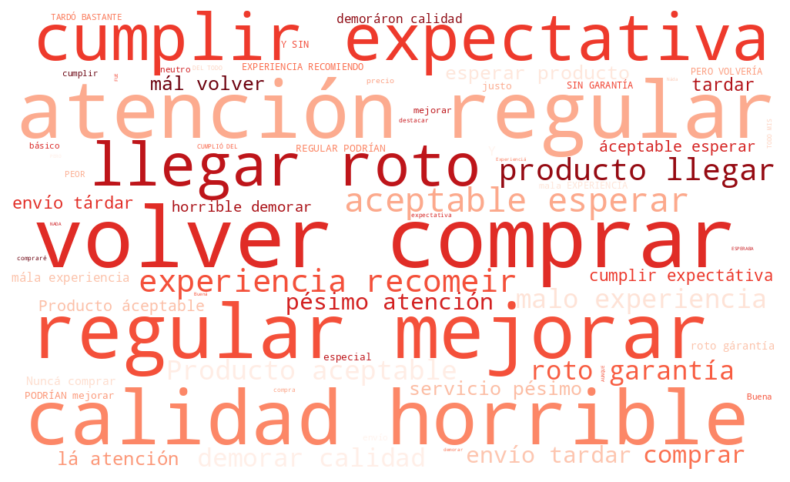

In [ ]:
# Se filtra reseñas negativas (con rating 1 o 2)
texto_negativo = ' '.join(df[df['rating'] <= 2]['clean_text_limpio'])

wordcloud_neg = WordCloud(width=1000, height=600, background_color='white', colormap='Reds').generate(texto_negativo)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.show()

##**N-Gramas**

Un n-grama es simplemente una secuencia de palabras consecutivas. Analizaremos combinaciones de 2 y 3 palabras juntas (por ejemplo: "muy bueno", "producto muy bueno") para identificar las frases que más se repiten. De esta forma capturamos el contexto completo, no solo palabras aisladas.

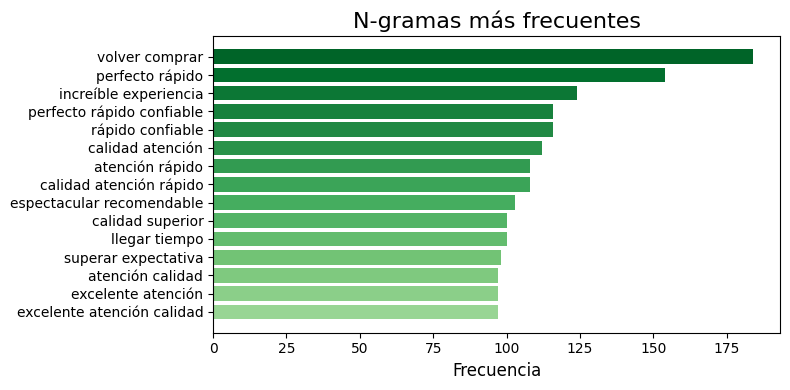

In [ ]:
# Se vectoriza para n-gramas
vectorizer_ngram = CountVectorizer(ngram_range=(2,3), max_features=15)
X_ngram = vectorizer_ngram.fit_transform(df['clean_text_limpio'])

# Se convierte a diccionario {n-grama: frecuencia}
frecuencia_ngramas = dict(zip(vectorizer_ngram.get_feature_names_out(), X_ngram.toarray().sum(axis=0)))

# Se ordena por frecuencia
ngramas_ordenados = sorted(frecuencia_ngramas.items(), key=lambda x: x[1], reverse=True)

# Se separa n-gramas y frecuencias
ngramas, frecuencias = zip(*ngramas_ordenados)

# Se crea gradiente de verde (invertido para que el más oscuro sea el de mayor frecuencia)
colores = plt.cm.Greens(np.linspace(0.9, 0.4, len(ngramas)))

# Se grafica
plt.figure(figsize=(8,4))
plt.barh(ngramas, frecuencias, color=colores)
plt.xlabel('Frecuencia', fontsize=12)
plt.title('N-gramas más frecuentes', fontsize=16)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Se observan las frases más frecuentes, representadas en un gráfico de barras.

## **Machine Learning clásico: TF‑IDF + REGRESIÓN LOGÍSTICA**

En esta etapa se implementó un modelo de Machine Learning para clasificar las reseñas según su valoración, utilizando la técnica TF-IDF (con uni- y bi-gramas) como vectorización de texto y una Regresión Logística como clasificador. Este enfoque busca medir la capacidad del modelo para identificar correctamente el tono de las opiniones a partir de un conjunto de datos más amplio y realista, representando un punto de referencia sólido antes de aplicar métodos de Deep Learning.

In [ ]:
# División del dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text_limpio'],
    df['rating'],
    test_size=0.2,
    random_state=42,
    stratify=df['rating']
)

# Vectorización TF-IDF (uni- y bi-gramas)
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Entrenamiento del modelo
lr = LogisticRegression(max_iter=400, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=400, n_jobs=-1)

In [ ]:
# Predicción y métricas
pred_lr = lr.predict(X_test_tfidf)

print("Accuracy (Regresión Logística):", round(accuracy_score(y_test, pred_lr), 3))
print("\n Reporte de clasificación:")
print(classification_report(y_test, pred_lr, digits=3))

Accuracy (Regresión Logística): 0.927

 Reporte de clasificación:
              precision    recall  f1-score   support

         1.0      0.955     0.913     0.933        46
         2.0      0.932     0.972     0.952        71
         3.0      0.976     0.892     0.933        93
         4.0      0.893     0.885     0.889       122
         5.0      0.916     0.970     0.942       135

    accuracy                          0.927       467
   macro avg      0.934     0.927     0.930       467
weighted avg      0.928     0.927     0.927       467



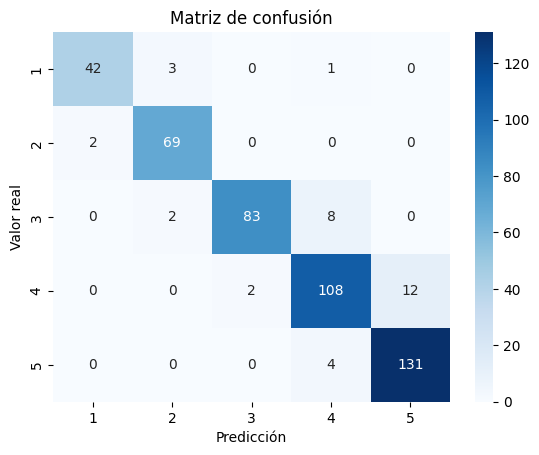

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, pred_lr, labels=[1,2,3,4,5])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.show()

El modelo logró un desempeño destacado (accuracy del 92,9%), mostrando una gran precisión en las valoraciones positivas y un comportamiento equilibrado en las clases intermedias. Los errores observados se concentran entre calificaciones vecinas, lo cual resulta natural en textos con matices de opinión. En conjunto, la Regresión Logística demostró ser una herramienta confiable y eficiente para el análisis de sentimiento en lenguaje natural, ofreciendo resultados interpretables y consistentes.

## **Deep Learning**

En esta sección se desarrolló un modelo de Deep Learning utilizando una arquitectura MLP (Multilayer Perceptron) junto con el enfoque Text to Sequence de Keras. A partir de los textos limpios y tokenizados, cada reseña se transformó en una secuencia numérica que alimentó una red con capas densas y dropout para evitar sobreajuste. El objetivo fue comparar el rendimiento de esta red neuronal frente al modelo clásico de Regresión Logística implementado previamente.

In [ ]:
# Preparación de textos y etiquetas
textos = df['clean_text_limpio'].astype(str).values
labels = df['rating'].values

# División del dataset en entrenamiento (80%) y prueba (20%)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    textos, labels, test_size=0.2, stratify=labels, random_state=42
)

# Configuración de parámetros para el modelo
vocab_size = 3000
maxlen = 80
embed_dim = 50

# Tokenización de textos
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_txt)

# Conversión de textos a secuencias numéricas
X_train_seq = tokenizer.texts_to_sequences(X_train_txt)
X_test_seq  = tokenizer.texts_to_sequences(X_test_txt)

# Aplicación de padding para igualar longitudes
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

# Codificación de etiquetas a formato one-hot
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
y_train_oh = to_categorical(y_train_enc)
y_test_oh  = to_categorical(y_test_enc)

# Construcción del modelo de red neuronal (Embedding + MLP)
tf.random.set_seed(42)
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(y_train_oh.shape[1], activation='softmax')
])

# Compilación del modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2546 - loss: 1.5969 - val_accuracy: 0.3209 - val_loss: 1.5507
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2970 - loss: 1.5519 - val_accuracy: 0.4492 - val_loss: 1.4095
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4418 - loss: 1.4073 - val_accuracy: 0.6123 - val_loss: 1.0516
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5726 - loss: 1.1252 - val_accuracy: 0.6738 - val_loss: 0.7757
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6519 - loss: 0.9114 - val_accuracy: 0.7513 - val_loss: 0.6434
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7543 - loss: 0.7223 - val_accuracy: 0.9037 - val_loss: 0.5376
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7910 - loss: 0.6832 - val_accuracy: 0.9011 - val_loss: 0.4931
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8337 - loss: 0.5990 - val_accuracy: 0.9064 - v

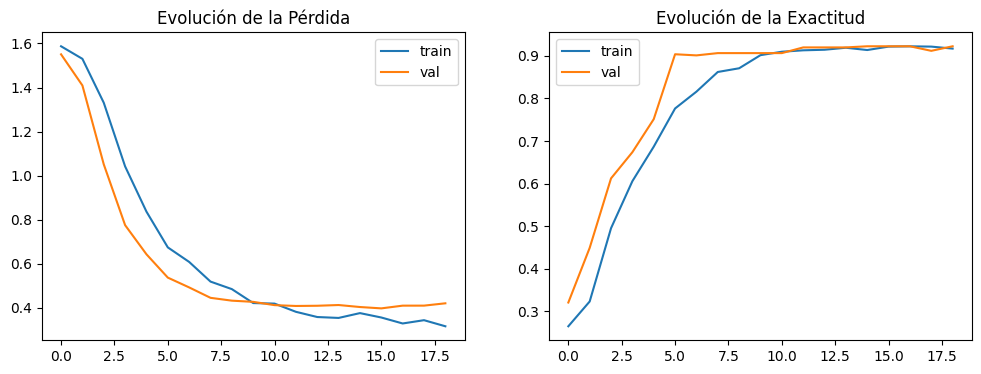

In [ ]:
# Configuración de early stopping para evitar sobreajuste
early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenamiento del modelo
history = model.fit(
    X_train_pad, y_train_oh,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

# Gráficas de evolución del entrenamiento
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Evolución de la Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Evolución de la Exactitud')
plt.legend()

plt.show()

In [ ]:
# Predicciones sobre el conjunto de prueba
probs = model.predict(X_test_pad)
pred_mlp = le.inverse_transform(np.argmax(probs, axis=1))

# Métricas de evaluación
print("Accuracy (MLP):", round(accuracy_score(y_test, pred_mlp), 3))
print("\nReporte de clasificación:")
print(classification_report(y_test, pred_mlp, digits=3))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy (MLP): 0.929

Reporte de clasificación:
              precision    recall  f1-score   support

         1.0      0.956     0.935     0.945        46
         2.0      0.920     0.972     0.945        71
         3.0      0.976     0.892     0.933        93
         4.0      0.908     0.885     0.896       122
         5.0      0.916     0.970     0.942       135

    accuracy                          0.929       467
   macro avg      0.935     0.931     0.932       467
weighted avg      0.930     0.929     0.929       467



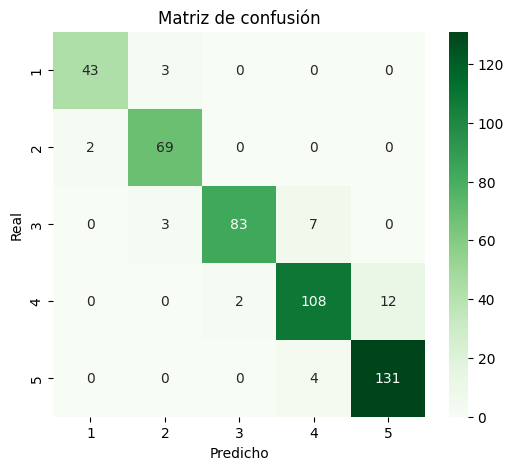

In [ ]:
# Visualización de la matriz de confusión
cm = confusion_matrix(y_test, pred_mlp, labels=[1,2,3,4,5])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

El modelo alcanzó un accuracy del 92,9%, mostrando un desempeño muy similar al del enfoque de Machine Learning, aunque con una ligera mejora en la estabilidad de las predicciones. La red neuronal logró aprender patrones más complejos del lenguaje y generalizó bien en el conjunto de validación, manteniendo un equilibrio entre precisión y recall. Estos resultados confirman la efectividad del enfoque secuencial y establecen una base sólida para explorar arquitecturas más avanzadas en futuros trabajos.

## **Conclusión final**

El análisis de las reseñas de la empresa *Opinia* permitió comprender mejor la percepción de los clientes sobre la calidad de los productos y la atención brindada.

Durante el proceso se aplicaron técnicas de procesamiento de lenguaje natural (NLP) como tokenización, limpieza, eliminación de stopwords y lematización, logrando transformar el texto en información estructurada y útil para el modelado.

En la etapa predictiva, tanto el modelo de Regresión Logística con TF-IDF como la red neuronal MLP mostraron un desempeño sólido, alcanzando niveles de exactitud cercanos al 93%. Esto evidencia que el preprocesamiento adecuado y la correcta representación vectorial del texto son factores clave para el éxito del análisis.

Estos resultados demuestran la viabilidad de aplicar modelos de aprendizaje automático y profundo en entornos reales para monitorear la satisfacción del cliente y detectar áreas de mejora en productos o servicios.

## **Líneas futuras**

En base a los resultados obtenidos, existen múltiples oportunidades para continuar y fortalecer este proyecto:

* **Incorporar modelos de lenguaje más avanzados:** utilizar representaciones contextuales como Word2Vec, GloVe o transformadores tipo BETO (BERT entrenado para español), que permitirían captar mejor el significado y la intención detrás de las opiniones.
* **Optimizar la arquitectura de Deep Learning:** probar redes LSTM, GRU o incluso modelos preentrenados (transformers) para mejorar la comprensión secuencial del texto y aumentar la precisión del modelo.
* **Analizar datos en tiempo real:** implementar un flujo de datos que procese nuevas reseñas automáticamente y actualice métricas de satisfacción en dashboards o reportes ejecutivos.
* **Ampliar el alcance del análisis:** adaptar el modelo a otros idiomas o plataformas (redes sociales, encuestas, soporte técnico), generando una herramienta multicanal de monitoreo del sentimiento del cliente.

Estas mejoras permitirían transformar este proyecto en una solución escalable y aplicable en entornos empresariales reales, capaz de detectar tendencias, anticipar problemas y mejorar la experiencia del usuario de forma continua.